# Detecção de Falhas em Sistemas Fotovoltaicos

Dado um conjunto de imagens que representam a termografia de um conjunto de módulos de placas solares, o intuito é classificar os módulos como defeituosos ou não baseado na termografia das imagens: áreas mais quentes tendem à causar problemas com os módulos, diminuindo a sua qualidade e causando, nos piores casos, problemas técnicos.

## Importando as bibliotecas

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import pandas

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score
)

## Carregando dataset: Photovoltaic System Thermography

In [83]:
import kagglehub

path1 = kagglehub.dataset_download("marcosgabriel/photovoltaic-system-thermography")

print("Path to dataset files:", path1)

Path to dataset files: /home/guilherme/.cache/kagglehub/datasets/marcosgabriel/photovoltaic-system-thermography/versions/3


## Conferindo a estrutura das pastas carregadas no dataset

Para esse projeto, utilizaremos o dataset_1 do conjunto de dados carregado.

In [84]:
import os
from pathlib import Path # para lidar com o pathing (caminhos) dos arquivos de imagem
from PIL import Image # chamando a biblioteca PIL para abrir e manipular as imagens
from collections import Counter # contador automático

dataset_path = path1 # definindo o path1 como o path do dataset
extensions = {".jpg", ".jpeg", ".png", ".bmp"} # extensões que são consideradas imagens

for subset in ["dataset_1"]: # realizando a iteração do conjunto
    subset_path = Path(dataset_path) / subset # passando pra subset_path o caminho do subset de dataset_1
    print(f"\n{'--------------------'}")
    print(f"Pasta [{subset}]")
    print(f"{'--------------------'}")

    for root, dirs, files in os.walk(subset_path): # percorrendo todas as subpastas
        level = root.replace(str(subset_path), "").count(os.sep) # calculando os níveis de profundidade ao entrar nas pastas
        indent = " " * 2 * level # a indentação visual da profundidade das pastas é salva em indent
        imgs = [f for f in files if Path(f).suffix.lower() in extensions] # passando para imgs, as imagens que foram encontradas
        outros = [f for f in files if Path(f).suffix.lower() not in extensions] # passando o resto que não é img (definido plas extensões) para outros
        print(f"{indent}{os.path.basename(root)}/") # exibe a pasta atual e a condicional caso seja uma imagem ou não
        if imgs:
            print(f"{indent}  > {len(imgs)} imagens") # exibe a quantidade de imagens
        if outros:
            print(f"{indent}  > outros arquivos: {outros[:5]}") #só os 5 primeiros que não são imagens


--------------------
Pasta [dataset_1]
--------------------
dataset_1/
  images/
    > 120 imagens
  annotations/
    > outros arquivos: ['027R.json', '032R.json', '117R.json', '059R.json', '020R.json']


## Localizando os arquivos de anotação do dataset_1

Os arquivos de anotação estarão associados com cada imagem e ela pode entregar para nós informações interessantes relacionadas as imagens tiradas dos datasets, como labels e metadados essenciais para a análise.

In [85]:
# Verificando os arquivos de anotação
print("Arquivos de anotação encontrados:\n")
# percorrendo as subpastas dos datasets 1 e 2
for p in Path(dataset_path).rglob("*"):
    # filtrando os arquivos que podem conter os meta dados pela extensão
    if p.suffix.lower() in {".csv", ".json", ".txt", ".xml", ".yaml"}:
        print(f"  {p}") # printando o pathing desse arquivo

Arquivos de anotação encontrados:

  /home/guilherme/.cache/kagglehub/datasets/marcosgabriel/photovoltaic-system-thermography/versions/3/dataset_1/annotations/027R.json
  /home/guilherme/.cache/kagglehub/datasets/marcosgabriel/photovoltaic-system-thermography/versions/3/dataset_1/annotations/032R.json
  /home/guilherme/.cache/kagglehub/datasets/marcosgabriel/photovoltaic-system-thermography/versions/3/dataset_1/annotations/117R.json
  /home/guilherme/.cache/kagglehub/datasets/marcosgabriel/photovoltaic-system-thermography/versions/3/dataset_1/annotations/059R.json
  /home/guilherme/.cache/kagglehub/datasets/marcosgabriel/photovoltaic-system-thermography/versions/3/dataset_1/annotations/020R.json
  /home/guilherme/.cache/kagglehub/datasets/marcosgabriel/photovoltaic-system-thermography/versions/3/dataset_1/annotations/054R.json
  /home/guilherme/.cache/kagglehub/datasets/marcosgabriel/photovoltaic-system-thermography/versions/3/dataset_1/annotations/118R.json
  /home/guilherme/.cache/ka

## Resolução e Modo de Cor

Precisamos ter ciência da resolução e a quantidade de canais de cor presentes nas imagens do dataset escolhido.

In [86]:
for subset in ["dataset_1"]:
    subset_path = Path(dataset_path) / subset
    
    sizes = Counter()
    modos = Counter()

    for p in subset_path.rglob("*"):
        if p.suffix.lower() in extensions:
            try:
                img = Image.open(p)
                sizes[img.size] += 1
                modos[img.mode] += 1
            except:
                pass

    print(f"\nPasta [{subset}]")
    print(f" > Resoluções: {dict(sizes.most_common(5))}")
    print(f" > Modos de cor: {dict(modos)}")


Pasta [dataset_1]
 > Resoluções: {(640, 512): 120}
 > Modos de cor: {'RGB': 120}


## Visualizando exemplos do subconjunto

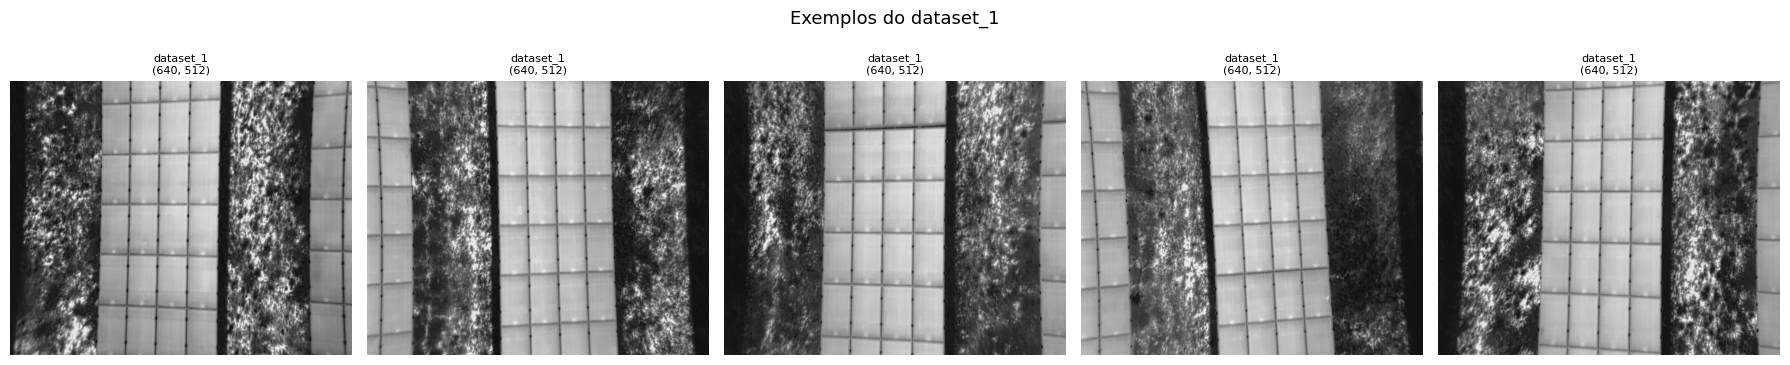

In [87]:
import random

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

subset_path = Path(dataset_path) / "dataset_1" / "images"
imgs = [p for p in subset_path.rglob("*") if p.suffix.lower() in extensions]
amostras = random.sample(imgs, min(5, len(imgs)))

for col, img_path in enumerate(amostras):
    img = Image.open(img_path)
    axes[col].imshow(img)
    axes[col].set_title(f"dataset_1\n{img.size}", fontsize=8)
    axes[col].axis("off")

plt.suptitle("Exemplos do dataset_1", fontsize=13)
plt.tight_layout()
plt.show()

## Inspecionando os metadados do `dataset_1`

É necessário observar atentamente a estrutura dos metadados contidos nos arquivos JSONs existentes na nossa base de dados.

In [88]:
import json

for subset in ["dataset_1"]:
    ann_path = Path(dataset_path) / subset / "annotations"
    jsons = list(ann_path.glob("*.json"))

    with open(jsons[0]) as f:
        data = json.load(f)

    print(f"\n=== Exemplo de JSON — {subset} ({jsons[0].name}) ===")
    print(json.dumps(data, indent=2)[:1500])


=== Exemplo de JSON — dataset_1 (027R.json) ===
{
  "instances": [
    {
      "corners": [
        {
          "x": 647.3014637532408,
          "y": 391.08313444038333
        },
        {
          "x": 627.8179182134461,
          "y": 389.6531494466369
        },
        {
          "x": 636.2190800517062,
          "y": 492.4333208721594
        },
        {
          "x": 648.9101968712055,
          "y": 493.1483133690326
        }
      ],
      "center": {
        "x": 640.0621647223996,
        "y": 441.5794795320531
      },
      "defected_module": false
    },
    {
      "corners": [
        {
          "x": 648.9101968712055,
          "y": 493.1483133690326
        },
        {
          "x": 636.2190800517062,
          "y": 492.4333208721594
        },
        {
          "x": 638.3640575423258,
          "y": 514.9555845236653
        },
        {
          "x": 652.6639074797898,
          "y": 514.240592026792
        }
      ],
      "center": {
        "x": 644

## Conferindo os *color channels* do `dataset_1`

In [89]:
for subset in ["dataset_1"]:
    subset_path = Path(dataset_path) / subset / "images"
    imgs = list(p for p in subset_path.rglob("*") if p.suffix.lower() in extensions)

    img = Image.open(imgs[0])
    arr = np.array(img)

    print(f"\n[{subset}] — exemplo: {imgs[0].name}")
    print(f"  Modo PIL:                    {img.mode}")
    print(f"  Shape da imagem (numpy):    {arr.shape}   → (altura, largura, canais)")
    print(f"  Número de canais:           {arr.shape[2]}")
    print(f"  Canal R — min/max: {arr[:,:,0].min()} / {arr[:,:,0].max()}")
    print(f"  Canal G — min/max: {arr[:,:,1].min()} / {arr[:,:,1].max()}")
    print(f"  Canal B — min/max: {arr[:,:,2].min()} / {arr[:,:,2].max()}")


[dataset_1] — exemplo: 081R.jpg
  Modo PIL:                    RGB
  Shape da imagem (numpy):    (512, 640, 3)   → (altura, largura, canais)
  Número de canais:           3
  Canal R — min/max: 15 / 237
  Canal G — min/max: 15 / 237
  Canal B — min/max: 15 / 237


## Decomposição dos canais de cor

Visualizando os 3 canais RGB separadamente para os dois subconjuntos.

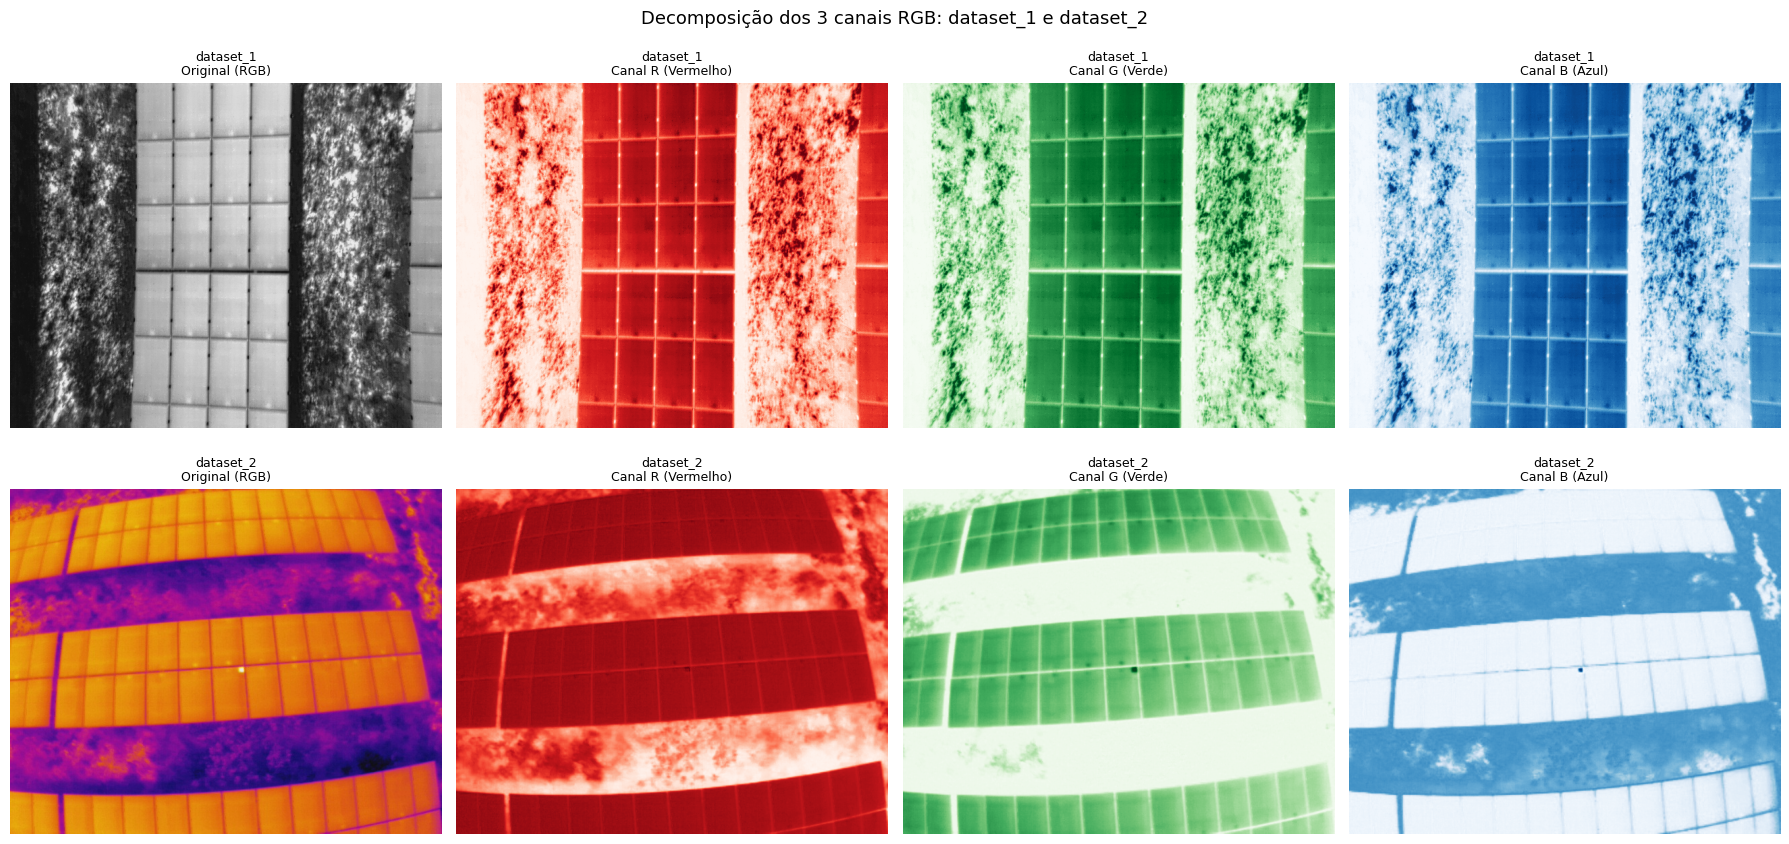

In [90]:
nomes_canais = ["Canal R (Vermelho)", "Canal G (Verde)", "Canal B (Azul)"]
cmaps = ["Reds", "Greens", "Blues"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for row, subset in enumerate(["dataset_1", "dataset_2"]):
    subset_path = Path(dataset_path) / subset / "images"
    imgs = list(p for p in subset_path.rglob("*") if p.suffix.lower() in extensions)

    img = Image.open(imgs[0])
    arr = np.array(img)

    axes[row][0].imshow(arr)
    axes[row][0].set_title(f"{subset}\nOriginal (RGB)", fontsize=9)

    for col in range(3):
        axes[row][col+1].imshow(arr[:, :, col], cmap=cmaps[col])
        axes[row][col+1].set_title(f"{subset}\n{nomes_canais[col]}", fontsize=9)

for ax in axes.flat:
    ax.axis("off")

plt.suptitle("Decomposição dos 3 canais RGB: dataset_1 e dataset_2", fontsize=13)
plt.tight_layout()
plt.show()

## Balanceamento: Distribuição dos Rótulos do `dataset_1`

Como podemos ver, o dataset está muito desbalanceado. O que pode comprometer o desempenho da rede neural, viesando o modelo.

In [91]:
for subset in ["dataset_1"]:
    ann_path = Path(dataset_path) / subset / "annotations"

    modulos_normais = 0
    modulos_defeituosos = 0
    total_instancias = 0

    for json_file in ann_path.glob("*.json"):
        with open(json_file) as f:
            data = json.load(f)
        for inst in data["instances"]:
            total_instancias += 1
            if inst["defected_module"]:
                modulos_defeituosos += 1
            else:
                modulos_normais += 1

    print(f"\n [{subset}]")
    print(f"Total de módulos anotados: {total_instancias}")
    print(f"> Módulos normais (False): {modulos_normais}  ({100*modulos_normais/total_instancias:.1f}%)")
    print(f"> Módulos defeituoso (True):  {modulos_defeituosos}  ({100*modulos_defeituosos/total_instancias:.1f}%)")


 [dataset_1]
Total de módulos anotados: 4107
> Módulos normais (False): 4081  (99.4%)
> Módulos defeituoso (True):  26  (0.6%)


# 1. Extração dos módulos, Redimensionamento e Normalização dos dados

Atualmente, a base de dados proporciona o *dataset_1* com fotos dos painéis fotovoltaicos inteiros. Nesse sentido, é preciso criar um dataset específico com os módulos individuais para detectar aqueles que são defeituosos ou não. Para isso, é necessário usar os cantos dos módulos denotados nos JSONs, recortando cada módulo e associando o *label* `defected_module` respectivo.

* **Crop:** recorte de cada módulo individual da imagem usando os `corners` do JSON
* **Resize:** redimensionamento para tamanho fixo de entrada da CNN (64×64)
* **Normalização:** escala 0–255 → 0.0–1.0 dividindo por 255

As imagens são mantidas em RGB (3 canais) para compatibilidade direta com os modelos pré-treinados ResNet50 e VGG16.

In [92]:
import cv2

dataset_path = path1
subset_path  = Path(dataset_path) / "dataset_1"
img_path     = subset_path / "images"
ann_path     = subset_path / "annotations"
extensions   = {".jpg", ".jpeg", ".png", ".bmp"}

modulos = []
labels  = []

for json_file in sorted(ann_path.glob("*.json")):
    img_file = img_path / (json_file.stem + ".jpg")
    if not img_file.exists():
        for ext in extensions:
            candidate = img_path / (json_file.stem + ext)
            if candidate.exists():
                img_file = candidate
                break

    img_array = np.array(Image.open(img_file))
    H, W      = img_array.shape[:2]

    with open(json_file) as f:
        data = json.load(f)

    for inst in data["instances"]:
        corners = inst["corners"]
        label   = int(inst["defected_module"])

        xs = [c["x"] for c in corners]
        ys = [c["y"] for c in corners]

        x_min = max(0, int(min(xs)))
        y_min = max(0, int(min(ys)))
        x_max = min(W, int(max(xs)))
        y_max = min(H, int(max(ys)))

        if x_max <= x_min or y_max <= y_min:
            continue
        if (x_max - x_min) < 5 or (y_max - y_min) < 5:
            continue

        crop = img_array[y_min:y_max, x_min:x_max]
        crop_resized = cv2.resize(crop, (64, 64))
        crop_normalizado = crop_resized.astype(np.float32) / 255.0  # shape: (64, 64, 3)

        modulos.append(crop_normalizado)
        labels.append(label)

modulos = np.array(modulos)  # shape: (N, 64, 64, 3)
labels = np.array(labels)

print(f"Total de módulos extraídos: {len(modulos)}")
print(f"Shape do array:             {modulos.shape}")
print(f"\nNormais     (0): {(labels == 0).sum()}")
print(f"Defeituosos (1): {(labels == 1).sum()}")
print(f"\nValor mínimo dos pixels: {modulos.min():.4f}")
print(f"Valor máximo dos pixels: {modulos.max():.4f}")

Total de módulos extraídos: 4086
Shape do array:             (4086, 64, 64, 3)

Normais     (0): 4060
Defeituosos (1): 26

Valor mínimo dos pixels: 0.0588
Valor máximo dos pixels: 0.9294


## 1.2. Visualização dos módulos extraídos e normalizados

Conferindo visualmente o crop realizado nas imagens.

Imagens exibidas com `cmap='gray'` e `.squeeze()` para evitar o tom esverdeado causado pelo colormap padrão do matplotlib ao receber imagens com shape incorreto.

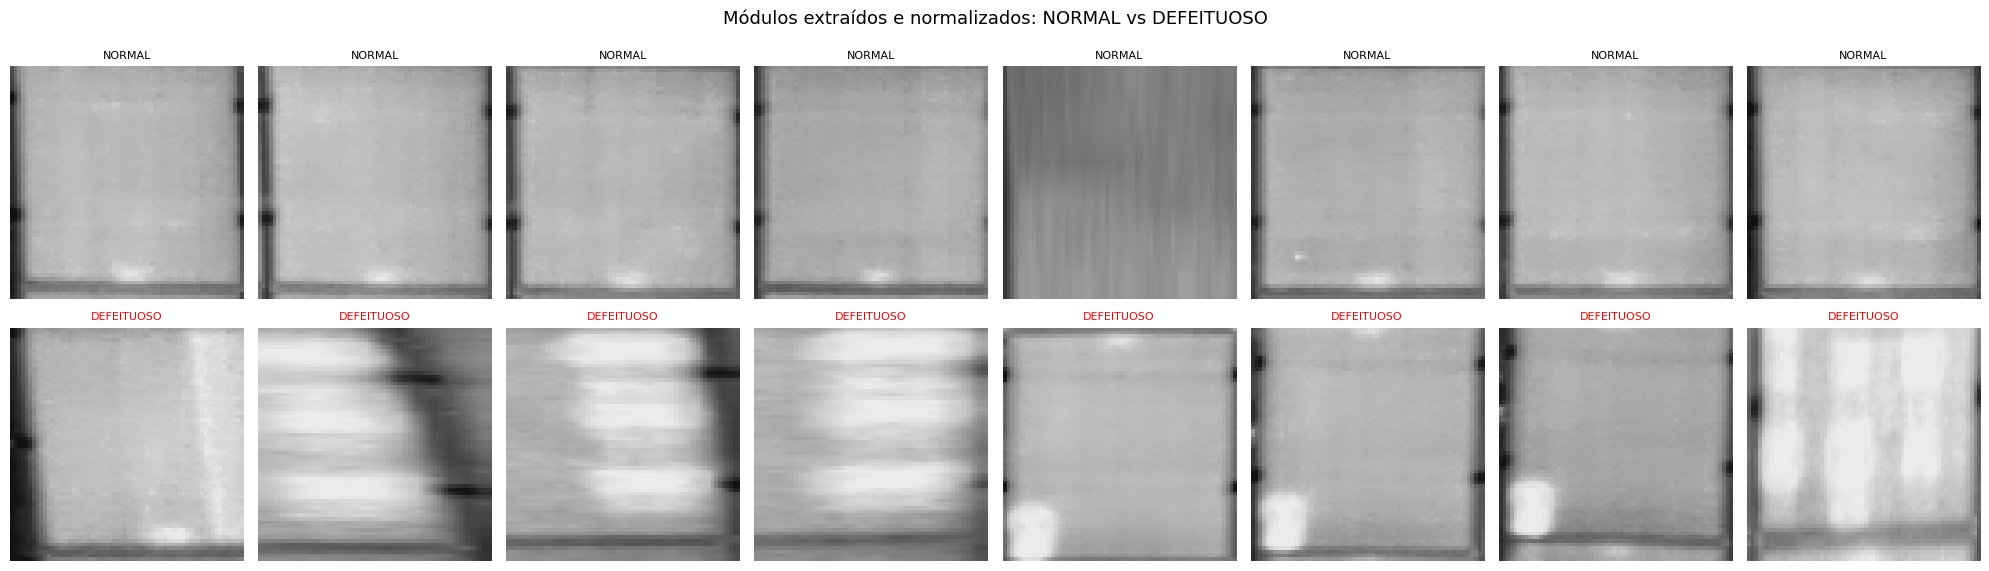

In [93]:
fig, axes = plt.subplots(2, 8, figsize=(20, 6))

# linha 0: módulos normais
normais_idx = np.where(labels == 0)[0]
for col, idx in enumerate(normais_idx[:8]):
    axes[0][col].imshow(modulos[idx])
    axes[0][col].set_title("NORMAL", fontsize=8)
    axes[0][col].axis("off")

# linha 1: módulos defeituosos
defeituosos_idx = np.where(labels == 1)[0]
for col, idx in enumerate(defeituosos_idx[:8]):
    axes[1][col].imshow(modulos[idx])
    axes[1][col].set_title("DEFEITUOSO", fontsize=8, color="red")
    axes[1][col].axis("off")

plt.suptitle("Módulos extraídos e normalizados: NORMAL vs DEFEITUOSO", fontsize=13)
plt.tight_layout()
plt.show()

# 2. Split inicial do conjunto de dados treino/validação/teste

A divisão do conjunto de dados será definida da seguinte forma:

- Proporção final: **60% treino / 20% validação / 20% teste**

O split é feito **antes** do data augmentation para evitar contaminação do conjunto de validação com imagens geradas artificialmente. O treino real é subdivido em 75% treino / 25% validação (do total de 80%), resultando na proporção final desejada.

In [94]:
X_real = modulos
y_real = labels

X_real, y_real = shuffle(X_real, y_real, random_state=42)

# 1ª divisão: 80% treino+val / 20% teste
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_real, y_real,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y_real
)

# 2ª divisão: 75% treino / 25% validação (= 60% e 20% do total)
X_train_real, X_val, y_train_real, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size    = 0.25,
    random_state = 42,
    stratify     = y_trainval
)

print(f"Total de amostras: {len(X_real)}")
print(f'-----------------------------------')
print(f"Treino (60%):      {len(X_train_real)} amostras")
print(f"  Normais:         {(y_train_real==0).sum()}")
print(f"  Defeituosos:     {(y_train_real==1).sum()}")
print(f'-----------------------------------')
print(f"Validação (20%):   {len(X_val)} amostras (dados REAIS)")
print(f"  Normais:         {(y_val==0).sum()}")
print(f"  Defeituosos:     {(y_val==1).sum()}")
print(f'-----------------------------------')
print(f"Teste (20%):       {len(X_test)} amostras (dados REAIS)")
print(f"  Normais:         {(y_test==0).sum()}")
print(f"  Defeituosos:     {(y_test==1).sum()}")

Total de amostras: 4086
-----------------------------------
Treino (60%):      2451 amostras
  Normais:         2435
  Defeituosos:     16
-----------------------------------
Validação (20%):   817 amostras (dados REAIS)
  Normais:         812
  Defeituosos:     5
-----------------------------------
Teste (20%):       818 amostras (dados REAIS)
  Normais:         813
  Defeituosos:     5


# 3.1. Balanceamento dos dados usando *Data Augmentation*

Como visto anteriormente, os dados estão fortemente desbalanceados (99.4% normal / 0.6% defeituoso). A estratégia aplicada é *oversampling* da classe minoritária usando `ImageDataGenerator`.

Vale mencionar que augmentation é aplicada APENAS em `X_train_real`, nunca na validação ou no teste.

In [95]:
X_def_train  = X_train_real[y_train_real == 1]
X_norm_train = X_train_real[y_train_real == 0]

n_gerar = len(X_norm_train) - len(X_def_train)
print(f'Defeituosos originais no treino:         {len(X_def_train)}')
print(f'Imagens a gerar artificialmente:         {n_gerar}')

datagen = ImageDataGenerator(
    rescale         = 1.0,
    rotation_range  = 180,
    horizontal_flip = True,
    vertical_flip   = True,
    zoom_range      = 0.1
)

X_aug = []
gerador = datagen.flow(X_def_train, batch_size=32, shuffle=True)

while len(X_aug) < n_gerar:
    batch = next(gerador)
    X_aug.extend(batch)

X_aug = np.clip(np.array(X_aug[:n_gerar]), 0.0, 1.0)

# monta treino balanceado
X_train = np.concatenate([X_norm_train, X_def_train, X_aug])
y_train = np.concatenate([
    np.zeros(len(X_norm_train)),
    np.ones(len(X_def_train) + len(X_aug))
]).astype(np.int32)

X_train, y_train = shuffle(X_train, y_train, random_state=42)

print(f"\nTreino balanceado: {len(X_train)} amostras")
print(f"> Normais:      {(y_train==0).sum()} ({100*(y_train==0).mean():.1f}%)")
print(f"> Defeituosos:  {(y_train==1).sum()} ({100*(y_train==1).mean():.1f}%)")

Defeituosos originais no treino:         16
Imagens a gerar artificialmente:         2419

Treino balanceado: 4870 amostras
> Normais:      2435 (50.0%)
> Defeituosos:  2435 (50.0%)


## 3.1.2. Visualização das imagens geradas pelo *Data Augmentation*


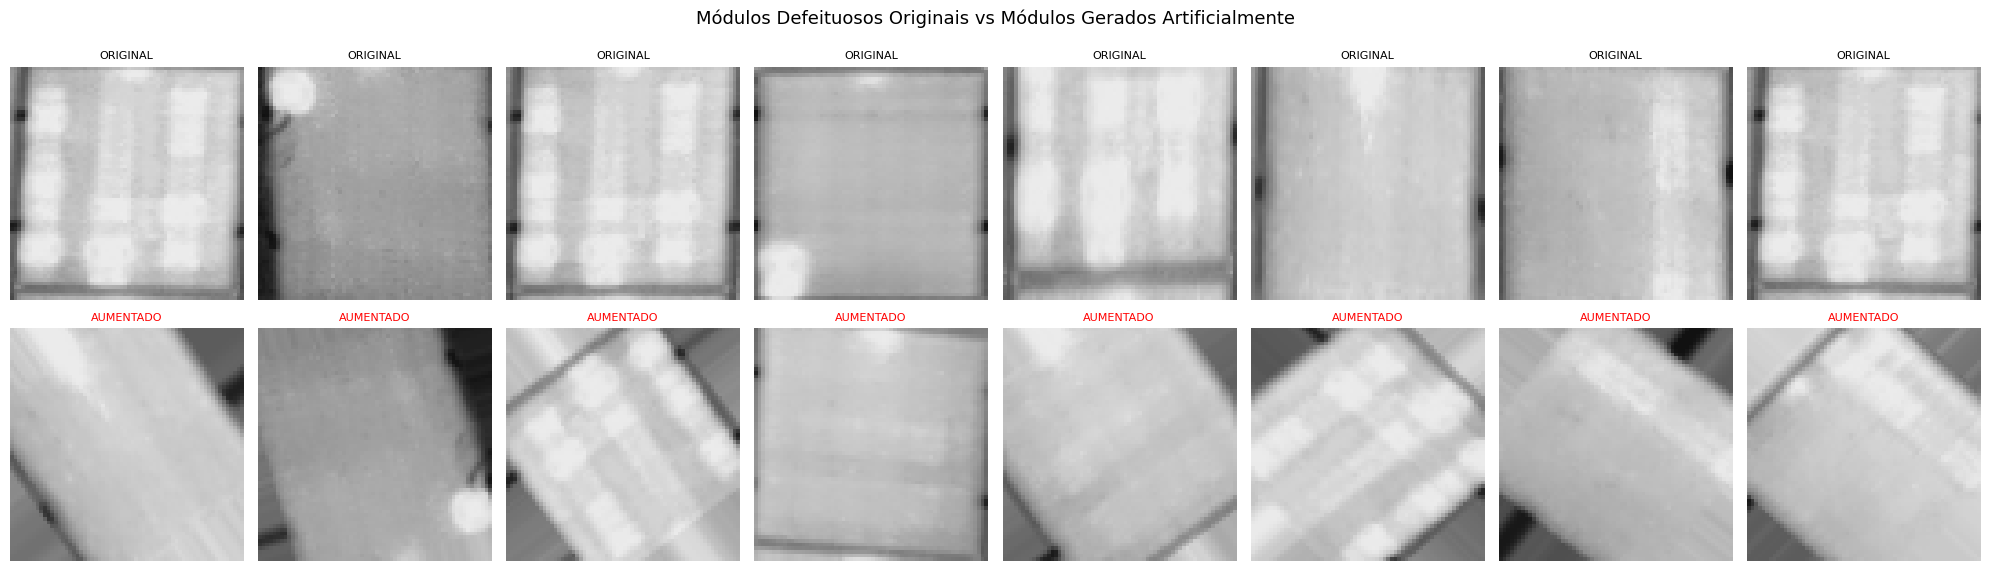

In [96]:
fig, axes = plt.subplots(2, 8, figsize=(20, 6))

# linha 0: defeituosos originais do treino
for col in range(min(8, len(X_def_train))):
    # CORREÇÃO: imagens RGB exibidas diretamente sem squeeze/cmap
    axes[0][col].imshow(X_def_train[col])
    axes[0][col].set_title("ORIGINAL", fontsize=8)
    axes[0][col].axis("off")

# linha 1: defeituosos gerados artificialmente
for col in range(8):
    axes[1][col].imshow(np.clip(X_aug[col], 0.0, 1.0))
    axes[1][col].set_title("AUMENTADO", fontsize=8, color="red")
    axes[1][col].axis("off")

plt.suptitle("Módulos Defeituosos Originais vs Módulos Gerados Artificialmente", fontsize=13)
plt.tight_layout()
plt.show()

# 3.2. Calculando o *Class Weights*

Além do data augmentation, atribuímos pesos maiores à classe defeituosa na função de loss. As duas estratégias são complementares:
- **Augmentation:** equilibra a quantidade de amostras
- **Class weight:** equilibra a importância de cada erro durante o treino

`compute_class_weight` calculado sobre `y_train_real` (dados desbalanceados originais), não sobre `y_train` (que já está 50/50 após o augmentation). Com `y_train` balanceado, os pesos ficariam ambos em 1.0, tornando o class_weight inútil.

In [97]:
classes = np.array([0, 1])

# usando y_train_real (desbalanceado) para calcular os pesos corretos
pesos = compute_class_weight(
    class_weight = 'balanced',
    classes      = classes,
    y            = y_train_real
)
class_weight_dict = {0: pesos[0], 1: pesos[1]}

print(f"Peso da classe Normal     (0): {pesos[0]:.4f}")
print(f"Peso da classe Defeituoso (1): {pesos[1]:.4f}")
print(f"\nInterpretação: errar um defeituoso custa {pesos[1]/pesos[0]:.1f}x mais que errar um normal.")

Peso da classe Normal     (0): 0.5033
Peso da classe Defeituoso (1): 76.5938

Interpretação: errar um defeituoso custa 152.2x mais que errar um normal.


# 4. Construção do Modelo CNN proprio

A arquitetura é composta por:
* 3 Blocos Convolucionais com `BatchNormalization` e `Dropout`
* `Flatten`
* MLP com `Dropout`
* Saída `sigmoid` para classificação binária

**CORREÇÃO:** `input_shape=(64, 64, 3)` — 3 canais RGB, compatível com os dados extraídos.

In [108]:
model = models.Sequential([
    # 3 canais RGB
    layers.Input(shape=(64, 64, 3)),

    # Bloco Convoluncional 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool2D((2,2)),

    # Bloco Convolucional 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPool2D((2,2)),

    # Bloco Convolucional 3
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    
    # Achatamento
    layers.Flatten(),

    # MLP
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,236,865 (4.72 MB)

 Trainable params: 1,236,545 (4.72 MB)

 Non-trainable params: 320 (1.25 KB)

# 5. Compilação do Modelo CNN proprio 

In [109]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss      = tf.keras.losses.BinaryCrossentropy(),
    metrics   = ['accuracy']
)

# 6. Treinamento do Modelo

1. `validation_data=(X_val, y_val)` para a validação com dados **reais**, não `validation_split`
2. `class_weight=class_weight_dict` — penaliza erros na classe defeituosa, + sensibilidade
3. `ReduceLROnPlateau` e usado para estabilizar a convergência

In [110]:
X_train, y_train = shuffle(X_train, y_train, random_state=40)

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.5,
    patience = 5,
    min_lr = 1e-7
)

history = model.fit(
    X_train, y_train,
    epochs = 100,
    validation_data = (X_val, y_val),
    batch_size = 32,
    callbacks = [early_stop, reduce_lr],
    class_weight = class_weight_dict
)

Epoch 1/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.5698 - loss: 2.3076 - val_accuracy: 0.0061 - val_loss: 2.2508 - learning_rate: 1.0000e-04
Epoch 2/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 100ms/step - accuracy: 0.7222 - loss: 0.5412 - val_accuracy: 0.0122 - val_loss: 2.4913 - learning_rate: 1.0000e-04
Epoch 3/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - accuracy: 0.8427 - loss: 0.3124 - val_accuracy: 0.0514 - val_loss: 2.6881 - learning_rate: 1.0000e-04
Epoch 4/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.9078 - loss: 0.1753 - val_accuracy: 0.6010 - val_loss: 1.0331 - learning_rate: 1.0000e-04
Epoch 5/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.9396 - loss: 0.1250 - val_accuracy: 0.5973 - val_loss: 1.2141 - learning_rate: 1.0000e-04
Epoch 6/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.9493 - loss: 0.1070 - val_accuracy: 0.9498 - val_loss: 0.1410 - learning_rate: 1.0000e-04
Epoch 7/100
153/153 ━━━━━━━━━━━━━━━━━━━━

# 7. Plotagem da Curva de Erro e Acurácia — CNN Própria


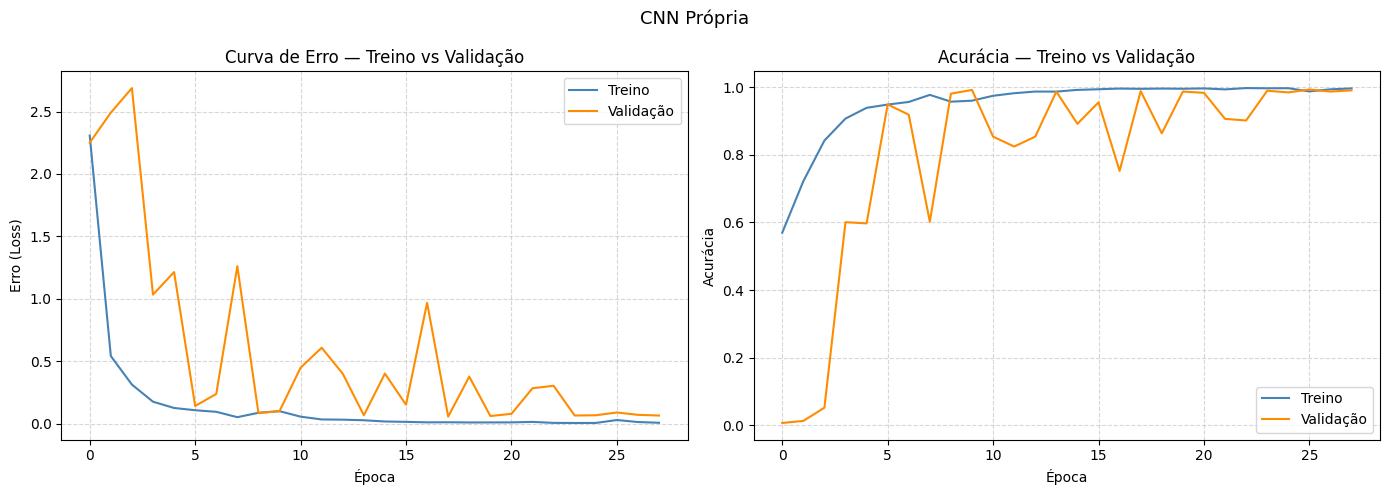

> Menor val_loss:          0.0559
> Época com menor val_loss: 18


In [111]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Erro (Loss)
axes[0].plot(history.history['loss'],     label='Treino',    color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validação', color='darkorange')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Erro (Loss)')
axes[0].set_title('Curva de Erro — Treino vs Validação')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Curva de Acurácia
axes[1].plot(history.history['accuracy'],     label='Treino',    color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validação', color='darkorange')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Acurácia — Treino vs Validação')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('CNN Própria', fontsize=13)
plt.tight_layout()
plt.show()

print(f"> Menor val_loss:          {min(history.history['val_loss']):.4f}")
print(f"> Época com menor val_loss: {np.argmin(history.history['val_loss'])+1}")

# 8. Avaliação do Conjunto de Teste — CNN Própria

As métricas mais relevantes para este problema são **F1-Score, Precision, Recall** e a **Matriz de Confusão**.

Vale mencionar que a acurácia sozinha é enganosa: um modelo que classifica tudo como "normal" já teria 99.4% de acurácia sem aprender nada.

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
============= Métricas no Conjunto de Teste — CNN Própria =============

                precision    recall  f1-score   support

    Normal (0)       1.00      1.00      1.00       813
Defeituoso (1)       0.25      0.20      0.22         5

      accuracy                           0.99       818
     macro avg       0.62      0.60      0.61       818
  weighted avg       0.99      0.99      0.99       818



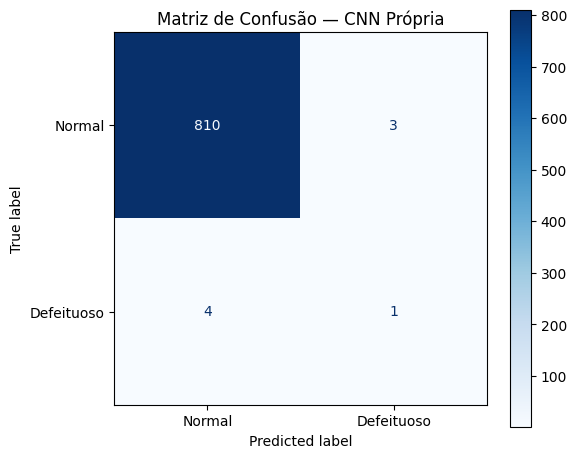


F1-Score (defeituoso): 0.2222
Precisão (defeituoso): 0.2500
Recall (defeituoso): 0.2000


In [112]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print("============= Métricas no Conjunto de Teste — CNN Própria =============\n")
print(classification_report(
    y_test, y_pred,
    target_names=["Normal (0)", "Defeituoso (1)"]
))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Normal", "Defeituoso"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", ax=ax)
ax.set_title("Matriz de Confusão — CNN Própria")
plt.tight_layout()
plt.show()

print(f"\nF1-Score (defeituoso): {f1_score(y_test, y_pred):.4f}")
print(f"Precisão (defeituoso): {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall (defeituoso): {recall_score(y_test, y_pred):.4f}")

# guarda métricas para comparação final
metricas_cnn = {
    "nome" : "CNN Própria",
    "f1" : f1_score(y_test, y_pred),
    "precision" : precision_score(y_test, y_pred, zero_division=0),
    "recall" : recall_score(y_test, y_pred)
}

# 9. Modelos Pré-Treinados

Dois modelos com Transfer Learning serão treinados e comparados com a CNN própria:
- **ResNet50** — rede residual profunda 
- **VGG16** — rede sequencial clássica com forte extração de features

Como as imagens já estão em RGB (3 canais), não é necessário nenhuma conversão adicional.

## 9.1. ResNet50 — Construção do Modelo

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# preprocessamento específico da ResNet50
# desfaz a normalização 0-1 para aplicar o preprocessamento original da rede
X_train_resnet = resnet_preprocess(X_train.copy() * 255)
X_val_resnet   = resnet_preprocess(X_val.copy() * 255)
X_test_resnet  = resnet_preprocess(X_test.copy() * 255)

# base pré-treinada sem a cabeça original (classificação ImageNet de 1000 classes)
base_resnet = ResNet50(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (64, 64, 3)
)
# congela os pesos convolucionais — só a cabeça nova será treinada
base_resnet.trainable = False

# nova cabeça de classificação adaptada ao problema binário
model_resnet = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 9.1. ResNet50 — Compilação

In [23]:
model_resnet.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss      = tf.keras.losses.BinaryCrossentropy(),
    metrics   = ['accuracy']
)

## 9.1. ResNet50 — Treinamento

In [ ]:
early_stop_resnet = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)

reduce_lr_resnet = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor = 0.5,
    patience = 5,
    min_lr = 1e-7
)

history_resnet = model_resnet.fit(
    X_train_resnet, y_train,
    epochs = 50,
    validation_data = (X_val_resnet, y_val),
    batch_size = 64,
    callbacks = [early_stop_resnet, reduce_lr_resnet],
    class_weight = class_weight_dict
)

Epoch 1/50


W0000 00:00:1777997700.422289  124631 cpu_allocator_impl.cc:82] Allocation of 239370240 exceeds 10% of free system memory.


77/77 ━━━━━━━━━━━━━━━━━━━━ 28s 265ms/step - accuracy: 0.5035 - loss: 5.0629 - val_accuracy: 0.0061 - val_loss: 4.6096 - learning_rate: 1.0000e-04
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step - accuracy: 0.5172 - loss: 1.1785 - val_accuracy: 0.0355 - val_loss: 2.5648 - learning_rate: 1.0000e-04
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 278ms/step - accuracy: 0.5729 - loss: 0.8902 - val_accuracy: 0.1285 - val_loss: 2.0041 - learning_rate: 1.0000e-04
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 274ms/step - accuracy: 0.6209 - loss: 0.7336 - val_accuracy: 0.2974 - val_loss: 1.4440 - learning_rate: 1.0000e-04
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 272ms/step - accuracy: 0.6842 - loss: 0.5929 - val_accuracy: 0.4125 - val_loss: 1.1957 - learning_rate: 1.0000e-04
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 21s 278ms/step - accuracy: 0.7411 - loss: 0.4728 - val_accuracy: 0.4761 - val_loss: 1.0882 - learning_rate: 1.0000e-04
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 20s 265ms/step - accuracy: 0.75

## 9.1. ResNet50 — Curvas de Treino

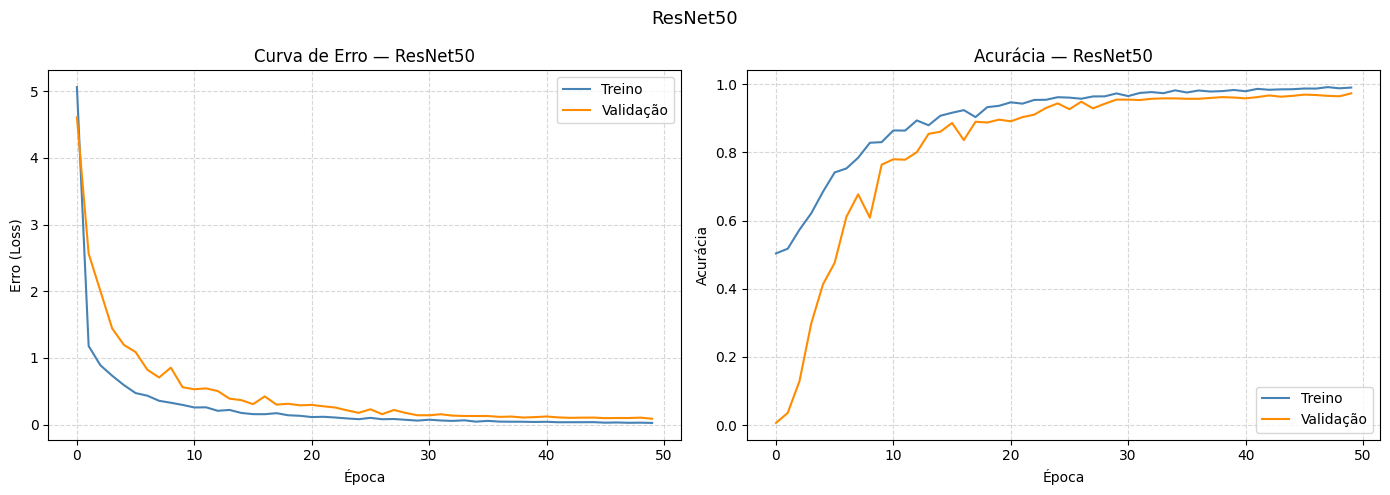

> Menor val_loss:          0.0880
> Época com menor val_loss: 50


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_resnet.history['loss'],     label='Treino',    color='steelblue')
axes[0].plot(history_resnet.history['val_loss'], label='Validação', color='darkorange')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Erro (Loss)')
axes[0].set_title('Curva de Erro — ResNet50')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(history_resnet.history['accuracy'],     label='Treino',    color='steelblue')
axes[1].plot(history_resnet.history['val_accuracy'], label='Validação', color='darkorange')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Acurácia — ResNet50')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('ResNet50', fontsize=13)
plt.tight_layout()
plt.show()

print(f"> Menor val_loss:          {min(history_resnet.history['val_loss']):.4f}")
print(f"> Época com menor val_loss: {np.argmin(history_resnet.history['val_loss'])+1}")

## 9.1. ResNet50 — Avaliação no Conjunto de Teste

26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step
============= Métricas no Conjunto de Teste — ResNet50 =============

                precision    recall  f1-score   support

    Normal (0)       1.00      0.99      0.99       813
Defeituoso (1)       0.08      0.20      0.12         5

      accuracy                           0.98       818
     macro avg       0.54      0.59      0.55       818
  weighted avg       0.99      0.98      0.99       818



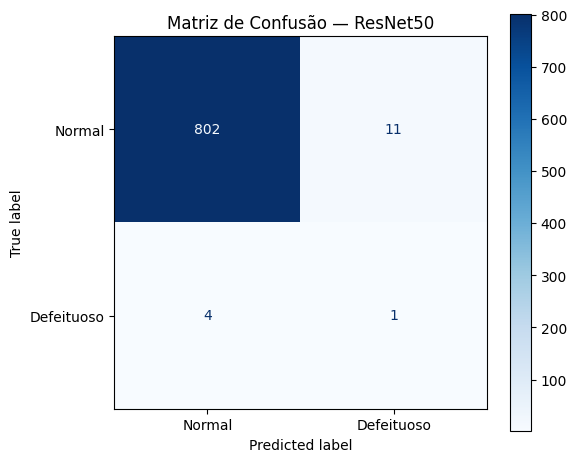


F1-Score  (defeituoso): 0.1176
Precisão  (defeituoso): 0.0833
Recall    (defeituoso): 0.2000


In [26]:
y_prob_resnet = model_resnet.predict(X_test_resnet).flatten()
y_pred_resnet = (y_prob_resnet >= 0.5).astype(int)

print("============= Métricas no Conjunto de Teste — ResNet50 =============\n")
print(classification_report(
    y_test, y_pred_resnet,
    target_names=["Normal (0)", "Defeituoso (1)"]
))

cm_resnet   = confusion_matrix(y_test, y_pred_resnet)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet,
                                      display_labels=["Normal", "Defeituoso"])
fig, ax = plt.subplots(figsize=(6, 5))
disp_resnet.plot(cmap="Blues", ax=ax)
ax.set_title("Matriz de Confusão — ResNet50")
plt.tight_layout()
plt.show()

print(f"\nF1-Score  (defeituoso): {f1_score(y_test, y_pred_resnet):.4f}")
print(f"Precisão  (defeituoso): {precision_score(y_test, y_pred_resnet, zero_division=0):.4f}")
print(f"Recall    (defeituoso): {recall_score(y_test, y_pred_resnet):.4f}")

metricas_resnet = {
    "nome"      : "ResNet50",
    "f1"        : f1_score(y_test, y_pred_resnet),
    "precision" : precision_score(y_test, y_pred_resnet, zero_division=0),
    "recall"    : recall_score(y_test, y_pred_resnet)
}

## 9.2. VGG16 — Construção do Modelo

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# preprocessamento específico do VGG16
X_train_vgg = vgg_preprocess(X_train.copy() * 255)
X_val_vgg   = vgg_preprocess(X_val.copy() * 255)
X_test_vgg  = vgg_preprocess(X_test.copy() * 255)

base_vgg = VGG16(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (64, 64, 3)
)
base_vgg.trainable = False

model_vgg = models.Sequential([
    base_vgg,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 40s 1us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## 9.2. VGG16 — Compilação

In [28]:
model_vgg.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss      = tf.keras.losses.BinaryCrossentropy(),
    metrics   = ['accuracy']
)

## 9.2. VGG16 — Treinamento

In [29]:
early_stop_vgg = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 10,
    restore_best_weights = True
)

reduce_lr_vgg = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 5,
    min_lr   = 1e-7
)

history_vgg = model_vgg.fit(
    X_train_vgg, y_train,
    epochs          = 50,
    validation_data = (X_val_vgg, y_val),
    batch_size      = 64,
    callbacks       = [early_stop_vgg, reduce_lr_vgg],
    class_weight    = class_weight_dict
)

Epoch 1/50


W0000 00:00:1777998808.634373  124631 cpu_allocator_impl.cc:82] Allocation of 239370240 exceeds 10% of free system memory.
W0000 00:00:1777998810.328643  124962 cpu_allocator_impl.cc:82] Allocation of 67108864 exceeds 10% of free system memory.
W0000 00:00:1777998810.345639  124962 cpu_allocator_impl.cc:82] Allocation of 67108864 exceeds 10% of free system memory.


77/77 ━━━━━━━━━━━━━━━━━━━━ 51s 644ms/step - accuracy: 0.5189 - loss: 3.4656 - val_accuracy: 0.0098 - val_loss: 6.8793 - learning_rate: 1.0000e-04
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 57s 737ms/step - accuracy: 0.5752 - loss: 2.0437 - val_accuracy: 0.0416 - val_loss: 4.2387 - learning_rate: 1.0000e-04
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 57s 739ms/step - accuracy: 0.5934 - loss: 1.6235 - val_accuracy: 0.0796 - val_loss: 3.5487 - learning_rate: 1.0000e-04
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 58s 751ms/step - accuracy: 0.6195 - loss: 1.4106 - val_accuracy: 0.1836 - val_loss: 2.8527 - learning_rate: 1.0000e-04
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 60s 778ms/step - accuracy: 0.6448 - loss: 1.2205 - val_accuracy: 0.1946 - val_loss: 2.8512 - learning_rate: 1.0000e-04
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 58s 752ms/step - accuracy: 0.7031 - loss: 0.9675 - val_accuracy: 0.4871 - val_loss: 1.5441 - learning_rate: 1.0000e-04
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 62s 809ms/step - accuracy: 0.74

## 9.2. VGG16 — Curvas de Treino

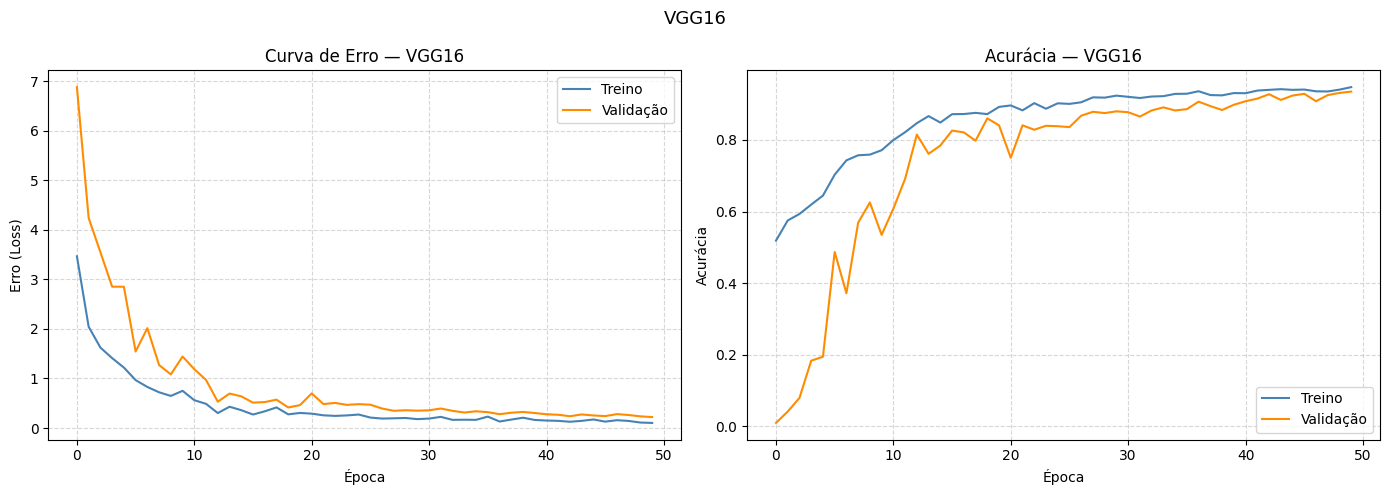

> Menor val_loss:          0.2208
> Época com menor val_loss: 50


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_vgg.history['loss'],     label='Treino',    color='steelblue')
axes[0].plot(history_vgg.history['val_loss'], label='Validação', color='darkorange')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Erro (Loss)')
axes[0].set_title('Curva de Erro — VGG16')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(history_vgg.history['accuracy'],     label='Treino',    color='steelblue')
axes[1].plot(history_vgg.history['val_accuracy'], label='Validação', color='darkorange')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].set_title('Acurácia — VGG16')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('VGG16', fontsize=13)
plt.tight_layout()
plt.show()

print(f"> Menor val_loss:          {min(history_vgg.history['val_loss']):.4f}")
print(f"> Época com menor val_loss: {np.argmin(history_vgg.history['val_loss'])+1}")

## 9.2. VGG16 — Avaliação no Conjunto de Teste

26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 321ms/step
============= Métricas no Conjunto de Teste — VGG16 =============

                precision    recall  f1-score   support

    Normal (0)       1.00      0.94      0.97       813
Defeituoso (1)       0.04      0.40      0.08         5

      accuracy                           0.94       818
     macro avg       0.52      0.67      0.52       818
  weighted avg       0.99      0.94      0.96       818



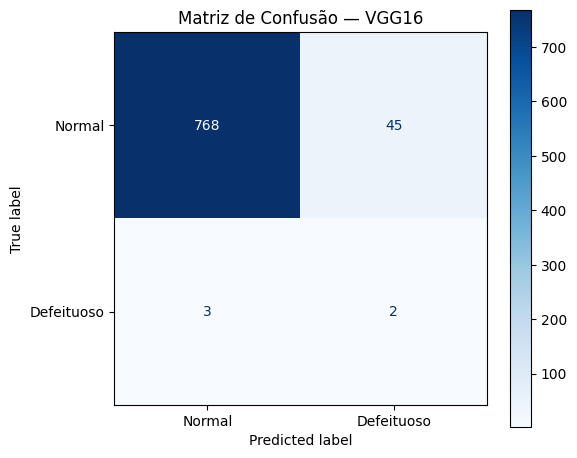


F1-Score  (defeituoso): 0.0769
Precisão  (defeituoso): 0.0426
Recall    (defeituoso): 0.4000


In [31]:
y_prob_vgg = model_vgg.predict(X_test_vgg).flatten()
y_pred_vgg = (y_prob_vgg >= 0.5).astype(int)

print("============= Métricas no Conjunto de Teste — VGG16 =============\n")
print(classification_report(
    y_test, y_pred_vgg,
    target_names=["Normal (0)", "Defeituoso (1)"]
))

cm_vgg   = confusion_matrix(y_test, y_pred_vgg)
disp_vgg = ConfusionMatrixDisplay(confusion_matrix=cm_vgg,
                                   display_labels=["Normal", "Defeituoso"])
fig, ax = plt.subplots(figsize=(6, 5))
disp_vgg.plot(cmap="Blues", ax=ax)
ax.set_title("Matriz de Confusão — VGG16")
plt.tight_layout()
plt.show()

print(f"\nF1-Score  (defeituoso): {f1_score(y_test, y_pred_vgg):.4f}")
print(f"Precisão  (defeituoso): {precision_score(y_test, y_pred_vgg, zero_division=0):.4f}")
print(f"Recall    (defeituoso): {recall_score(y_test, y_pred_vgg):.4f}")

metricas_vgg = {
    "nome"      : "VGG16",
    "f1"        : f1_score(y_test, y_pred_vgg),
    "precision" : precision_score(y_test, y_pred_vgg, zero_division=0),
    "recall"    : recall_score(y_test, y_pred_vgg)
}

# 10. Comparação dos 3 Modelos

Tabela e gráfico comparativo das métricas de F1-Score, Precisão e Recall para os três modelos avaliados no conjunto de teste.


Modelo                 F1-Score   Precisão     Recall
----------------------------------------------------
  CNN Própria            0.2222     0.2500     0.2000
  ResNet50               0.1176     0.0833     0.2000
  VGG16                  0.0769     0.0426     0.4000


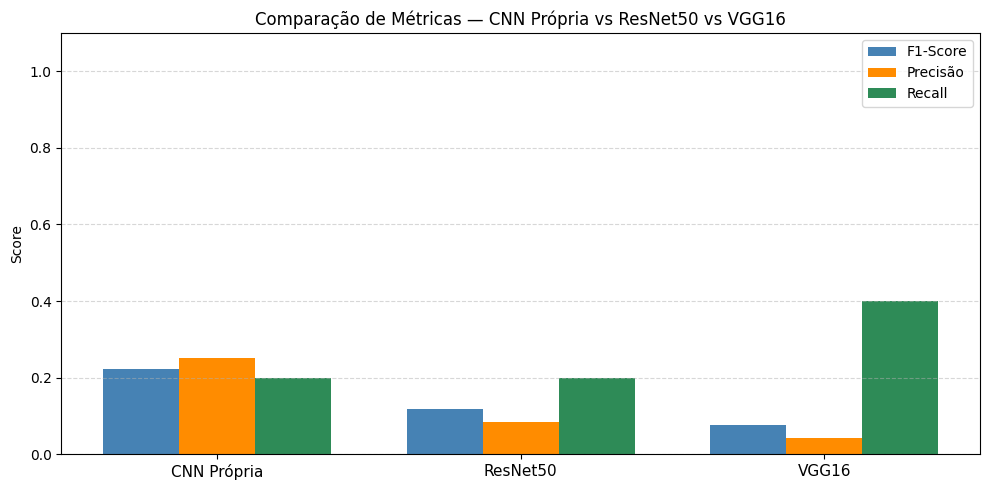

In [113]:
todos = [metricas_cnn, metricas_resnet, metricas_vgg]

print(f"\n{'Modelo':<20} {'F1-Score':>10} {'Precisão':>10} {'Recall':>10}")
print("-" * 52)
for m in todos:
    print(f"  {m['nome']:<18} {m['f1']:>10.4f} {m['precision']:>10.4f} {m['recall']:>10.4f}")

# gráfico comparativo
nomes = [m["nome"] for m in todos]
f1s   = [m["f1"] for m in todos]
precs = [m["precision"] for m in todos]
recs  = [m["recall"] for m in todos]

x = np.arange(len(nomes))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, f1s, width=w, label='F1-Score', color='steelblue')
ax.bar(x, precs, width=w, label='Precisão', color='darkorange')
ax.bar(x + w, recs, width=w, label='Recall', color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(nomes, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparação de Métricas — CNN Própria vs ResNet50 vs VGG16')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()